Dataset path: /kaggle/input/datasets/shreyansdeshpande/cnnfinale/FINALCNNDATA_FINAL
Dataset exists: True
Statistics path: /kaggle/working/channel_stats.npz
Training patches: 2549
Validation patches: 523
Testing patches: 545
Existing channel statistics loaded.

Channel means shape: (11,)
Channel standard deviations shape: (11,)
Channel  1: mean = 0.035586, std = 0.008933
Channel  2: mean = 0.043991, std = 0.016917
Channel  3: mean = 0.035915, std = 0.014176
Channel  4: mean = 0.254984, std = 0.099669
Channel  5: mean = 0.015495, std = 0.724850
Channel  6: mean = 7.437615, std = 6.348506
Channel  7: mean = 0.929927, std = 0.052677
Channel  8: mean = 0.634771, std = 0.089876
Channel  9: mean = 0.631415, std = 0.091906
Channel 10: mean = 0.632500, std = 0.090122
Channel 11: mean = 0.636035, std = 0.092484

Image batch shape: torch.Size([16, 11, 250, 250])
Label batch shape: torch.Size([16])

Using device: cuda
Epoch 1/15 | Train Loss: 0.6345 | Train Accuracy: 66.50% | Validation Loss: 0.57

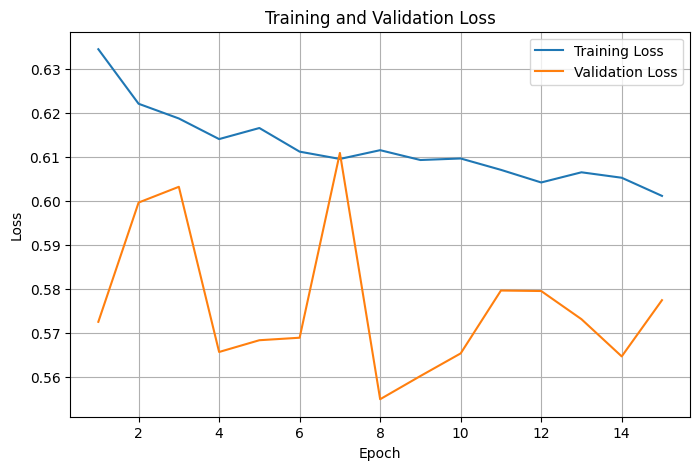

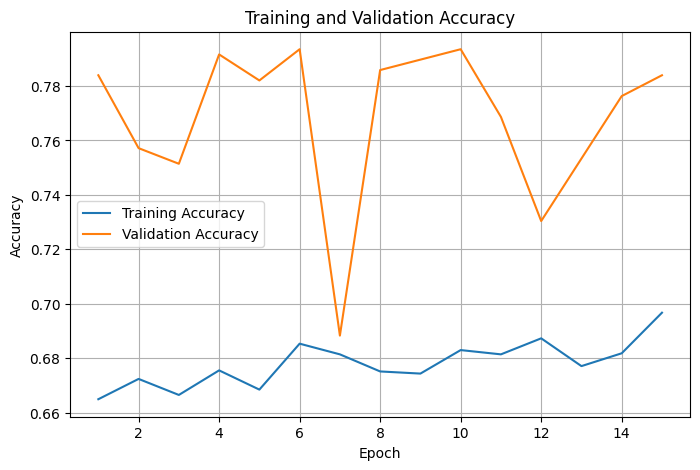

Validation samples: 523
Test samples: 545

BEST VALIDATION THRESHOLD
Best threshold : 0.37
Precision      : 0.2654
Recall         : 0.7748
F1 score       : 0.3954

Number of true positives: 86
Mean probability on correctly-identified sites: 0.437
Min/Max: 0.370 / 0.643
Percentiles (10/25/50/75/90): [0.37955059 0.39381129 0.41513784 0.4675146  0.53372848]


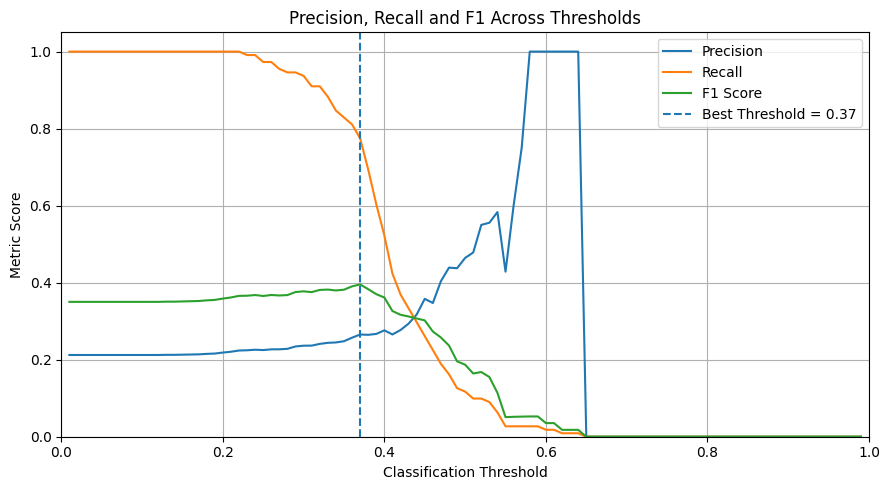


TEST RESULTS AT THRESHOLD 0.50
Threshold : 0.50
Accuracy  : 0.7009 (70.09%)
Precision : 0.5446
Recall    : 0.3526
F1 Score  : 0.4281
ROC-AUC   : 0.6930

Confusion Matrix:
[[321  51]
 [112  61]]

TEST RESULTS AT BEST VALIDATION THRESHOLD
Threshold : 0.37
Accuracy  : 0.5394 (53.94%)
Precision : 0.3946
Recall    : 0.8439
F1 Score  : 0.5378
ROC-AUC   : 0.6930

Confusion Matrix:
[[148 224]
 [ 27 146]]


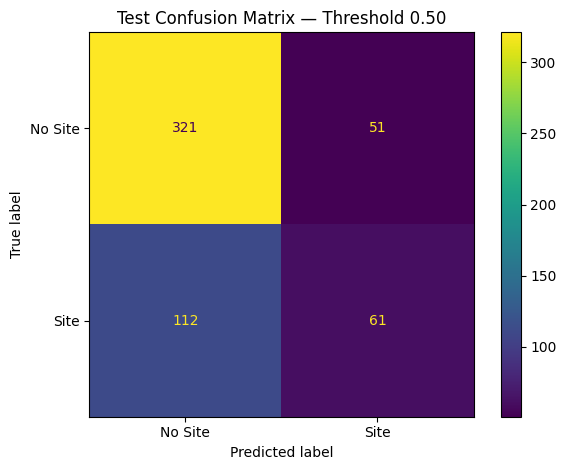

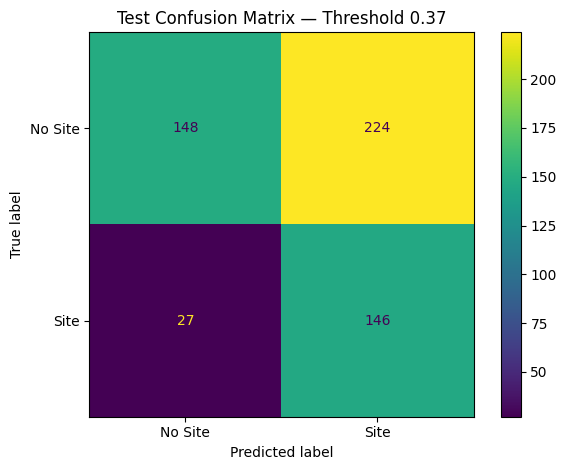

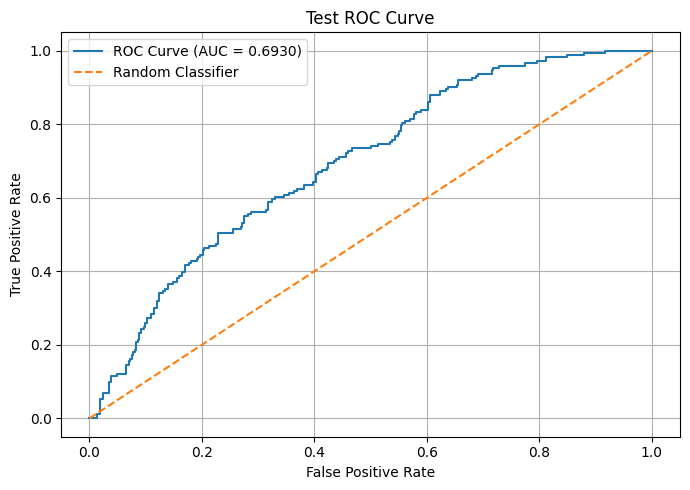


Evaluation files saved inside /kaggle/working/


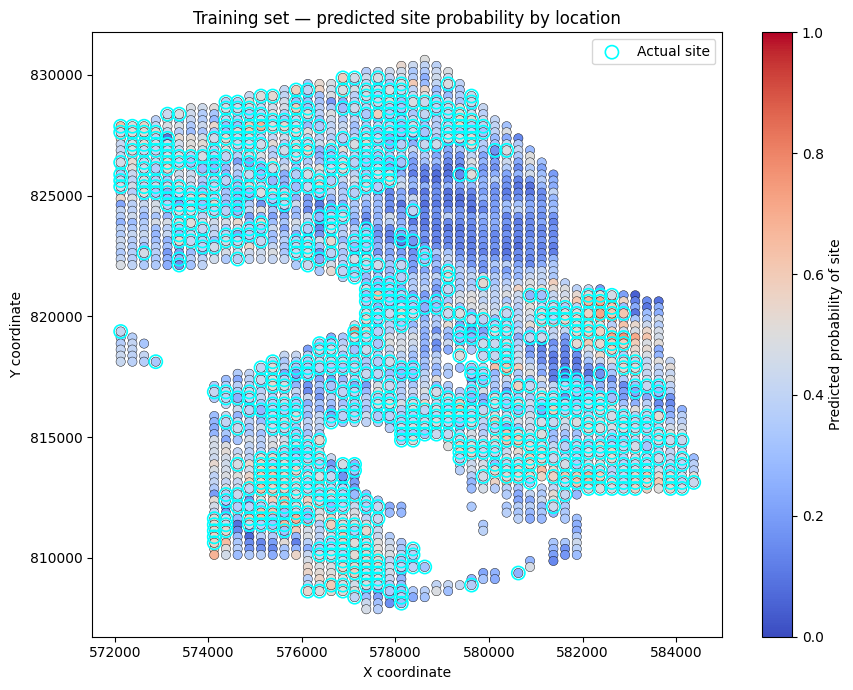

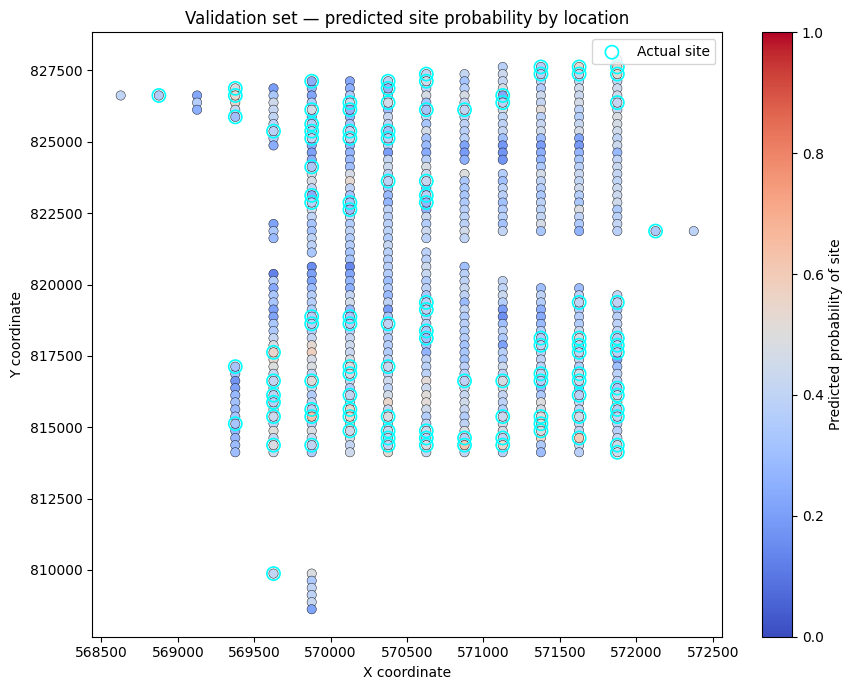

Model weights saved to /kaggle/working/model_20260808_191622.pth
Model architecture code saved to /kaggle/working/model_code_20260808_191622.py

Run logged to /kaggle/working/experiment_log.csv


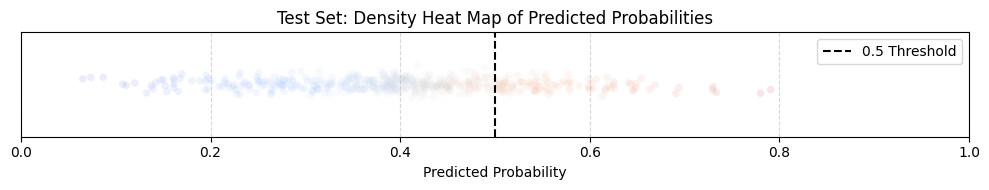

NameError: name 'falsePositiveIndices' is not defined

In [14]:
# 1. IMPORT LIBRARIES
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm


# 2. KAGGLE DATASET PATHS

# Dataset is already extracted inside Kaggle Input
datasetPath = Path(
    "/kaggle/input/datasets/shreyansdeshpande/"
    "cnnfinale/FINALCNNDATA_FINAL"
)

# Kaggle Input is read-only, so save generated files here
statsPath = Path(
    "/kaggle/working/channel_stats.npz"
)


if not datasetPath.exists():
    raise FileNotFoundError(
        f"Dataset folder not found:\n{datasetPath}"
    )


print("Dataset path:", datasetPath)
print("Dataset exists:", datasetPath.exists())
print("Statistics path:", statsPath)
import csv
import inspect
from datetime import datetime

resultsLogPath = Path("/kaggle/working/experiment_log.csv")

# 3. COLLECT TRAIN, VALIDATION AND TEST RECORDS

#Labelling data record
classMapping = {
    "no_site": 0,
    "site": 1
}


def collectRecords(splitName):

    records = []

    for className, label in classMapping.items():

        folderPath = (
            datasetPath
            / splitName
            / className
        )

        if not folderPath.exists():
            raise FileNotFoundError(
                f"Folder not found:\n{folderPath}"
            )

        tifFiles = sorted(
            list(folderPath.glob("*.tif"))
            + list(folderPath.glob("*.tiff"))
        )

        for filePath in tifFiles:
            records.append(
                (filePath, label)
            )

    return records


trainRecords = collectRecords(
    "train"
)

validationRecords = collectRecords(
    "validation"
)

testRecords = collectRecords(
    "test"
)


print("Training patches:", len(trainRecords))
print("Validation patches:", len(validationRecords))
print("Testing patches:", len(testRecords))

# 4. CALCULATE OR LOAD CHANNEL STATISTICS
numChannels = 11


def calculateChannelStats(records):

    channelSum = np.zeros(
        numChannels,
        dtype=np.float64
    )

    channelSquaredSum = np.zeros(
        numChannels,
        dtype=np.float64
    )

    channelPixelCount = np.zeros(
        numChannels,
        dtype=np.int64
    )

    for filePath, label in tqdm(
        records,
        desc="Calculating channel statistics"
    ):

        with rasterio.open(filePath) as raster:

            image = raster.read(
                masked=True
            ).astype(np.float64)

        for channelIndex in range(numChannels):

            validValues = (
                image[channelIndex]
                .compressed()
            )

            validValues = validValues[
                np.isfinite(validValues)
            ]

            if validValues.size == 0:
                continue

            channelSum[channelIndex] += (
                validValues.sum()
            )

            channelSquaredSum[channelIndex] += (
                np.square(validValues).sum()
            )

            channelPixelCount[channelIndex] += (
                validValues.size
            )

    if np.any(channelPixelCount == 0):
        raise ValueError(
            "At least one channel contains no valid pixels."
        )

    channelMeans = (
        channelSum
        / channelPixelCount
    )

    channelVariances = (
        channelSquaredSum
        / channelPixelCount
        - np.square(channelMeans)
    )

    channelVariances = np.maximum(
        channelVariances,
        1e-12
    )

    channelStds = np.sqrt(
        channelVariances
    )

    return (
        channelMeans.astype(np.float32),
        channelStds.astype(np.float32)
    )


if statsPath.exists():

    savedStats = np.load(
        statsPath
    )

    channelMeans = savedStats[
        "means"
    ]

    channelStds = savedStats[
        "stds"
    ]

    print("Existing channel statistics loaded.")

else:

    channelMeans, channelStds = (
        calculateChannelStats(
            trainRecords
        )
    )

    np.savez(
        statsPath,
        means=channelMeans,
        stds=channelStds
    )

    print("Channel statistics calculated and saved.")


print("\nChannel means shape:", channelMeans.shape)
print("Channel standard deviations shape:", channelStds.shape)

for channelIndex in range(numChannels):

    print(
        f"Channel {channelIndex + 1:2d}: "
        f"mean = {channelMeans[channelIndex]:.6f}, "
        f"std = {channelStds[channelIndex]:.6f}"
    )

# 5. CREATE THE PYTORCH DATASET
class ArchaeologyDataset(Dataset):

    def __init__(
        self,
        records,
        channelMeans,
        channelStds,
        augment=False
    ):
        self.records = records
        self.augment = augment
        

        self.channelMeans = (
            channelMeans
            .reshape(numChannels, 1, 1)
            .astype(np.float32)
        )

        self.channelStds = (
            channelStds
            .reshape(numChannels, 1, 1)
            .astype(np.float32)
        )

    def __len__(self):

        return len(self.records)

    def __getitem__(self, index):

        filePath, label = self.records[index]

        with rasterio.open(filePath) as raster:

            image = raster.read(
                masked=True
            ).astype(np.float32)

        image = image.filled(
            np.nan
        )

        for channelIndex in range(numChannels):

            invalidPixels = ~np.isfinite(
                image[channelIndex]
            )

            image[channelIndex][invalidPixels] = (
                self.channelMeans[
                    channelIndex,
                    0,
                    0
                ]
            )

        image = (
            image - self.channelMeans
        ) / self.channelStds
        if self.augment:
              if np.random.rand() < 0.5:
                 image = np.flip(image, axis=2).copy()
              if np.random.rand() < 0.5:
                 image = np.flip(image, axis=1).copy()
              numRotations = np.random.randint(0, 4)
              if numRotations > 0:
                 image = np.rot90(image, k=numRotations, axes=(1, 2)).copy()
                  
        imageTensor = torch.from_numpy(
            image
        ).float()

        labelTensor = torch.tensor(
            label,
            dtype=torch.float32
        )

        return imageTensor, labelTensor


trainDataset = ArchaeologyDataset(
    trainRecords,
    channelMeans,
    channelStds,
    augment=True
)

validationDataset = ArchaeologyDataset(
    validationRecords,
    channelMeans,
    channelStds,
    augment=False
)

testDataset = ArchaeologyDataset(
    testRecords,
    channelMeans,
    channelStds,
    augment=False
)
# 6. CREATE THE DATALOADERS

batchSize = 16

trainLoader = DataLoader(
    trainDataset,
    batch_size=batchSize,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

validationLoader = DataLoader(
    validationDataset,
    batch_size=batchSize,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

testLoader = DataLoader(
    testDataset,
    batch_size=batchSize,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


images, labels = next(
    iter(trainLoader)
)

print("\nImage batch shape:", images.shape)
print("Label batch shape:", labels.shape)

# 7. DEFINE THE CNN MODEL

class ArchaeologyCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                11,
                16,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2)
        )

        self.globalPool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(
                128,
                1
            )
        )

    def forward(self, x):

        x = self.features(x)
        x = self.globalPool(x)
        x = self.classifier(x)

        return x

# 8. DEVICE, LOSS AND OPTIMIZER
runTimestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("\nUsing device:", device)

model = ArchaeologyCNN().to(
    device
)

# pos_weight up-weights the rare "site" class so the model
# isn't rewarded for just predicting "no_site" every time
numNoSite = sum(1 for _, label in trainRecords if label == 0)
numSite = sum(1 for _, label in trainRecords if label == 1)


optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0003,
    weight_decay=0.0001
)


scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',       # We want the validation loss to decrease
    factor=0.1,       # Multiply the learning rate by 0.1 when plateauing
    patience=3,       # Number of epochs with no improvement before reducing LR
    
)


# 9. TRAIN AND VALIDATE THE MODEL
numEpochs = 15

trainLosses = []
validationLosses = []

trainAccuracies = []
validationAccuracies = []


for epoch in range(numEpochs):

    # ---------------------------------------------------------
    # TRAINING
    # ---------------------------------------------------------

    model.train()

    totalTrainLoss = 0.0
    correctTrain = 0
    totalTrain = 0

    for images, labels in trainLoader:

        images = images.to(
            device
        )

        labels = (
            labels
            .to(device)
            .float()
            .view(-1, 1)
        )

        optimizer.zero_grad()

        outputs = model(
            images
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        currentBatchSize = images.size(
            0
        )

        totalTrainLoss += (
            loss.item()
            * currentBatchSize
        )

        probabilities = torch.sigmoid(
            outputs
        )

        predictions = (
            probabilities >= 0.5
        ).long()

        correctTrain += (
            predictions
            == labels.long()
        ).sum().item()

        totalTrain += currentBatchSize


    trainLoss = (
        totalTrainLoss
        / totalTrain
    )

    trainAccuracy = (
        correctTrain
        / totalTrain
    )


    # ---------------------------------------------------------
    # VALIDATION
    # ---------------------------------------------------------

    model.eval()

    totalValidationLoss = 0.0
    correctValidation = 0
    totalValidation = 0

    with torch.no_grad():

        for images, labels in validationLoader:

            images = images.to(
                device
            )

            labels = (
                labels
                .to(device)
                .float()
                .view(-1, 1)
            )

            outputs = model(
                images
            )

            loss = criterion(
                outputs,
                labels
            )

            currentBatchSize = images.size(
                0
            )

            totalValidationLoss += (
                loss.item()
                * currentBatchSize
            )

            probabilities = torch.sigmoid(
                outputs
            )

            predictions = (
                probabilities >= 0.5
            ).long()

            correctValidation += (
                predictions
                == labels.long()
            ).sum().item()

            totalValidation += currentBatchSize


    validationLoss = (
        totalValidationLoss
        / totalValidation
    )

    validationAccuracy = (
        correctValidation
        / totalValidation
    )


    trainLosses.append(
        trainLoss
    )

    validationLosses.append(
        validationLoss
    )

    trainAccuracies.append(
        trainAccuracy
    )

    validationAccuracies.append(
        validationAccuracy
    )

    scheduler.step(validationLoss)
    print(
        f"Epoch {epoch + 1}/{numEpochs} | "
        f"Train Loss: {trainLoss:.4f} | "
        f"Train Accuracy: {trainAccuracy * 100:.2f}% | "
        f"Validation Loss: {validationLoss:.4f} | "
        f"Validation Accuracy: {validationAccuracy * 100:.2f}%"
    )


# 10. PLOT THE RESULTS
epochs = range(
    1,
    numEpochs + 1
)


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    epochs,
    trainLosses,
    label="Training Loss"
)

plt.plot(
    epochs,
    validationLosses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    epochs,
    trainAccuracies,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    validationAccuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

# =========================================================
# MODEL EVALUATION AND THRESHOLD ANALYSIS
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# =========================================================
# 1. COLLECT LABELS AND PROBABILITIES
# =========================================================

def collectPredictions(model, dataLoader, device):

    model.eval()

    allLabels = []
    allProbabilities = []

    with torch.no_grad():

        for images, labels in dataLoader:

            images = images.to(
                device
            )

            outputs = model(
                images
            )

            probabilities = torch.sigmoid(
                outputs
            ).squeeze(1)

            allLabels.extend(
                labels.cpu().numpy().astype(int)
            )

            allProbabilities.extend(
                probabilities.cpu().numpy()
            )

    return (
        np.array(allLabels),
        np.array(allProbabilities)
    )


# Validation predictions are used to choose the threshold
validationLabels, validationProbabilities = (
    collectPredictions(
        model,
        validationLoader,
        device
    )
)

# Test predictions are used for final evaluation
testLabels, testProbabilities = (
    collectPredictions(
        model,
        testLoader,
        device
    )
)


print(
    "Validation samples:",
    len(validationLabels)
)

print(
    "Test samples:",
    len(testLabels)
)


# =========================================================
# 2. TEST DIFFERENT THRESHOLDS ON VALIDATION DATA
# =========================================================

thresholdValues = np.linspace(
    0.01,
    0.99,
    99
)

thresholdPrecisions = []
thresholdRecalls = []
thresholdF1Scores = []


for threshold in thresholdValues:

    predictions = (
        validationProbabilities >= threshold
    ).astype(int)

    precision = precision_score(
        validationLabels,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        validationLabels,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        validationLabels,
        predictions,
        zero_division=0
    )

    thresholdPrecisions.append(
        precision
    )

    thresholdRecalls.append(
        recall
    )

    thresholdF1Scores.append(
        f1
    )


thresholdPrecisions = np.array(
    thresholdPrecisions
)

thresholdRecalls = np.array(
    thresholdRecalls
)

thresholdF1Scores = np.array(
    thresholdF1Scores
)


bestThresholdIndex = np.argmax(
    thresholdF1Scores
)

bestThreshold = thresholdValues[
    bestThresholdIndex
]


print("\nBEST VALIDATION THRESHOLD")
print("=" * 45)

print(
    f"Best threshold : {bestThreshold:.2f}"
)

print(
    f"Precision      : "
    f"{thresholdPrecisions[bestThresholdIndex]:.4f}"
)

print(
    f"Recall         : "
    f"{thresholdRecalls[bestThresholdIndex]:.4f}"
)

print(
    f"F1 score       : "
    f"{thresholdF1Scores[bestThresholdIndex]:.4f}"
)


predictions = (validationProbabilities >= bestThreshold).astype(int)

truePositiveMask = (validationLabels == 1) & (predictions == 1)
truePositiveProbs = validationProbabilities[truePositiveMask]

print(f"\nNumber of true positives: {truePositiveMask.sum()}")
print(f"Mean probability on correctly-identified sites: {truePositiveProbs.mean():.3f}")
print(f"Min/Max: {truePositiveProbs.min():.3f} / {truePositiveProbs.max():.3f}")
print(f"Percentiles (10/25/50/75/90):", np.percentile(truePositiveProbs, [10, 25, 50, 75, 90]))

# =========================================================
# 3. PLOT METRICS AT DIFFERENT THRESHOLDS
# =========================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    thresholdValues,
    thresholdPrecisions,
    label="Precision"
)

plt.plot(
    thresholdValues,
    thresholdRecalls,
    label="Recall"
)

plt.plot(
    thresholdValues,
    thresholdF1Scores,
    label="F1 Score"
)

plt.axvline(
    bestThreshold,
    linestyle="--",
    label=f"Best Threshold = {bestThreshold:.2f}"
)

plt.xlabel(
    "Classification Threshold"
)

plt.ylabel(
    "Metric Score"
)

plt.title(
    "Precision, Recall and F1 Across Thresholds"
)

plt.xlim(
    0,
    1
)

plt.ylim(
    0,
    1.05
)

plt.legend()
plt.grid()
plt.tight_layout()

plt.savefig(
    "/kaggle/working/threshold_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 4. EVALUATION FUNCTION
# =========================================================

def calculateMetrics(
    labels,
    probabilities,
    threshold
):

    predictions = (
        probabilities >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision = precision_score(
        labels,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        labels,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        labels,
        predictions,
        zero_division=0
    )

    if len(np.unique(labels)) == 2:

        rocAuc = roc_auc_score(
            labels,
            probabilities
        )

    else:

        rocAuc = np.nan

    matrix = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1]
    )

    return {
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": rocAuc,
        "predictions": predictions,
        "confusion_matrix": matrix
    }


# Results at normal threshold
defaultResults = calculateMetrics(
    testLabels,
    testProbabilities,
    threshold=0.5
)

# Results at best validation threshold
bestThresholdResults = calculateMetrics(
    testLabels,
    testProbabilities,
    threshold=bestThreshold
)


# =========================================================
# 5. PRINT TEST RESULTS
# =========================================================

def printResults(
    resultName,
    results
):

    print(
        f"\n{resultName}"
    )

    print(
        "=" * 50
    )

    print(
        f"Threshold : "
        f"{results['threshold']:.2f}"
    )

    print(
        f"Accuracy  : "
        f"{results['accuracy']:.4f} "
        f"({results['accuracy'] * 100:.2f}%)"
    )

    print(
        f"Precision : "
        f"{results['precision']:.4f}"
    )

    print(
        f"Recall    : "
        f"{results['recall']:.4f}"
    )

    print(
        f"F1 Score  : "
        f"{results['f1']:.4f}"
    )

    print(
        f"ROC-AUC   : "
        f"{results['roc_auc']:.4f}"
    )

    print(
        "\nConfusion Matrix:"
    )

    print(
        results["confusion_matrix"]
    )


printResults(
    "TEST RESULTS AT THRESHOLD 0.50",
    defaultResults
)

printResults(
    "TEST RESULTS AT BEST VALIDATION THRESHOLD",
    bestThresholdResults
)


# =========================================================
# 6. CONFUSION MATRIX AT THRESHOLD 0.50
# =========================================================

display = ConfusionMatrixDisplay(
    confusion_matrix=defaultResults[
        "confusion_matrix"
    ],
    display_labels=[
        "No Site",
        "Site"
    ]
)

display.plot(
    values_format="d"
)

plt.title(
    "Test Confusion Matrix — Threshold 0.50"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/confusion_matrix_050.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 7. CONFUSION MATRIX AT BEST THRESHOLD
# =========================================================

display = ConfusionMatrixDisplay(
    confusion_matrix=bestThresholdResults[
        "confusion_matrix"
    ],
    display_labels=[
        "No Site",
        "Site"
    ]
)

display.plot(
    values_format="d"
)

plt.title(
    f"Test Confusion Matrix — Threshold {bestThreshold:.2f}"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/confusion_matrix_best_threshold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 8. ROC CURVE
# =========================================================

if len(np.unique(testLabels)) == 2:

    falsePositiveRate, truePositiveRate, rocThresholds = (
        roc_curve(
            testLabels,
            testProbabilities
        )
    )

    testRocAuc = roc_auc_score(
        testLabels,
        testProbabilities
    )

    plt.figure(
        figsize=(7, 5)
    )

    plt.plot(
        falsePositiveRate,
        truePositiveRate,
        label=f"ROC Curve (AUC = {testRocAuc:.4f})"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random Classifier"
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.title(
        "Test ROC Curve"
    )

    plt.legend()
    plt.grid()
    plt.tight_layout()

    plt.savefig(
        "/kaggle/working/roc_curve.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

else:

    print(
        "ROC curve cannot be calculated because "
        "the test set contains only one class."
    )


print(
    "\nEvaluation files saved inside /kaggle/working/"
)

# =========================================================
# 9. SPATIAL HEATMAP OF PREDICTIONS
# (training set and validation set, plotted separately)
# =========================================================

def collectSpatialPredictions(
    model,
    records,
    channelMeans,
    channelStds,
    device
):

    model.eval()

    meansReshaped = (
        channelMeans
        .reshape(numChannels, 1, 1)
        .astype(np.float32)
    )

    stdsReshaped = (
        channelStds
        .reshape(numChannels, 1, 1)
        .astype(np.float32)
    )

    xs = []
    ys = []
    probs = []
    trueLabels = []

    with torch.no_grad():

        for filePath, label in tqdm(
            records,
            desc="Collecting spatial predictions"
        ):

            with rasterio.open(filePath) as raster:

                image = raster.read(
                    masked=True
                ).astype(np.float32)

                bounds = raster.bounds

            centerX = (
                bounds.left + bounds.right
            ) / 2

            centerY = (
                bounds.bottom + bounds.top
            ) / 2

            image = image.filled(
                np.nan
            )

            for channelIndex in range(numChannels):

                invalidPixels = ~np.isfinite(
                    image[channelIndex]
                )

                image[channelIndex][invalidPixels] = (
                    meansReshaped[
                        channelIndex,
                        0,
                        0
                    ]
                )

            image = (
                image - meansReshaped
            ) / stdsReshaped

            imageTensor = torch.from_numpy(
                image
            ).float().unsqueeze(0).to(device)

            output = model(
                imageTensor
            )

            probability = torch.sigmoid(
                output
            ).item()

            xs.append(centerX)
            ys.append(centerY)
            probs.append(probability)
            trueLabels.append(label)

    return (
        np.array(xs),
        np.array(ys),
        np.array(probs),
        np.array(trueLabels)
    )


def plotSpatialHeatmap(
    xs,
    ys,
    probs,
    trueLabels,
    title,
    savePath
):

    plt.figure(
        figsize=(9, 7)
    )

    scatter = plt.scatter(
        xs,
        ys,
        c=probs,
        cmap="coolwarm",
        s=45,
        edgecolor="black",
        linewidth=0.3,
        vmin=0,
        vmax=1
    )

    # Outline actual known sites so predicted probability
    # can be visually compared against ground truth location
    siteMask = trueLabels == 1

    plt.scatter(
        xs[siteMask],
        ys[siteMask],
        facecolors="none",
        edgecolors="cyan",
        linewidth=1.2,
        s=90,
        label="Actual site"
    )

    plt.colorbar(
        scatter,
        label="Predicted probability of site"
    )

    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.title(title)
    plt.legend(loc="upper right")
    plt.tight_layout()

    plt.savefig(
        savePath,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


trainXs, trainYs, trainProbs, trainSpatialLabels = (
    collectSpatialPredictions(
        model,
        trainRecords,
        channelMeans,
        channelStds,
        device
    )
)

plotSpatialHeatmap(
    trainXs,
    trainYs,
    trainProbs,
    trainSpatialLabels,
    "Training set — predicted site probability by location",
    "/kaggle/working/spatial_heatmap_train.png"
)

validationXs, validationYs, validationProbs, validationSpatialLabels = (
    collectSpatialPredictions(
        model,
        validationRecords,
        channelMeans,
        channelStds,
        device
    )
)

plotSpatialHeatmap(
    validationXs,
    validationYs,
    validationProbs,
    validationSpatialLabels,
    "Validation set — predicted site probability by location",
    "/kaggle/working/spatial_heatmap_validation.png"
)

# =========================================================
# 10. SAVE MODEL, ARCHITECTURE CODE, AND LOG RESULTS
# =========================================================

# Save model weights for this run
modelSavePath = f"/kaggle/working/model_{runTimestamp}.pth"
torch.save(model.state_dict(), modelSavePath)
print(f"Model weights saved to {modelSavePath}")

modelCodePath = f"/kaggle/working/model_code_{runTimestamp}.py"
try:
    architectureSource = inspect.getsource(ArchaeologyCNN)
except OSError:
    architectureSource = (
        "# Source unavailable: ArchaeologyCNN was defined "
        "interactively in the notebook, not in a .py file."
    )
with open(modelCodePath, "w") as f:
    f.write(architectureSource)
print(f"Model architecture code saved to {modelCodePath}")

# Build the log row
runRecord = {
    "timestamp": runTimestamp,
    "numChannels": numChannels,
    "batchSize": batchSize,
    "numEpochs": numEpochs,
    "learningRate": optimizer.param_groups[0]["lr"],
    "weightDecay": optimizer.param_groups[0]["weight_decay"],
    "posWeight": posWeightValue,
    "finalTrainLoss": trainLosses[-1],
    "finalValLoss": validationLosses[-1],
    "finalTrainAcc": trainAccuracies[-1],
    "finalValAcc": validationAccuracies[-1],
    "bestThreshold": bestThreshold,
    "test_accuracy_050": defaultResults["accuracy"],
    "test_precision_050": defaultResults["precision"],
    "test_recall_050": defaultResults["recall"],
    "test_f1_050": defaultResults["f1"],
    "test_rocauc_050": defaultResults["roc_auc"],
    "test_accuracy_bestThresh": bestThresholdResults["accuracy"],
    "test_precision_bestThresh": bestThresholdResults["precision"],
    "test_recall_bestThresh": bestThresholdResults["recall"],
    "test_f1_bestThresh": bestThresholdResults["f1"],
    "test_rocauc_bestThresh": bestThresholdResults["roc_auc"],
    "modelSavePath": modelSavePath,
    "modelCodePath": modelCodePath,
}

# Append to CSV (creates file + header on first run, appends after that)
fileExists = resultsLogPath.exists()

with open(resultsLogPath, mode="a", newline="") as csvFile:
    writer = csv.DictWriter(csvFile, fieldnames=runRecord.keys())
    if not fileExists:
        writer.writeheader()
    writer.writerow(runRecord)

print(f"\nRun logged to {resultsLogPath}")

# =========================================================
# 11. 1D LINEAR DOT HEAT MAP FOR PROBABILITIES
# =========================================================

def plotLinearDotHeatmap(probabilities, title, savePath):
    # Keep the figure short and wide to emphasize the 1D nature
    plt.figure(figsize=(10, 2))
    
    # Add a tiny bit of random vertical noise so dots don't perfectly stack 
    # on top of each other. This makes density much easier to see.
    jitter = np.random.normal(0, 0.05, size=len(probabilities))
    
    # Scatter plot with transparency to create the heatmap effect
    scatter = plt.scatter(
        probabilities, 
        jitter, 
        alpha=0.1,          # Highly transparent: dense clusters will appear solid
        c=probabilities,    # Color matches the probability value
        cmap='coolwarm',    # Blue for 0.0, Red for 1.0
        s=30,               # Size of the dots
        edgecolors='none'
    )
    
    # Formatting the visual
    plt.xlim(0, 1)
    plt.ylim(-0.5, 0.5)
    plt.yticks([])  # Remove y-axis ticks since the y-axis is just random jitter
    plt.xlabel("Predicted Probability")
    plt.title(title)
    
    # Add a line showing the default 0.5 threshold
    plt.axvline(0.5, color='black', linestyle='--', label='0.5 Threshold')
    
    plt.legend(loc="upper right")
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    plt.savefig(savePath, dpi=300, bbox_inches="tight")
    plt.show()

# Execute the function using the test predictions already in memory
plotLinearDotHeatmap(
    testProbabilities,
    title="Test Set: Density Heat Map of Predicted Probabilities",
    savePath="/kaggle/working/probability_dot_heatmap.png"
)

def visualizePatch(filePath, label, predictedProb, numChannels):
    with rasterio.open(filePath) as raster:
        image = raster.read(masked=True).astype(np.float32)
        image = image.filled(np.nan)

    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    axes = axes.flatten()

    for i in range(numChannels):
        axes[i].imshow(image[i], cmap="viridis")
        axes[i].set_title(f"Ch {i+1}")
        axes[i].axis("off")

    fig.suptitle(
        f"{filePath.name} | true label={label} | predicted prob={predictedProb:.3f}"
    )
    plt.tight_layout()
    plt.show()


# Look at the top 3 worst false positives
for idx in falsePositiveIndices[:3]:
    filePath, label = validationRecords[idx]
    visualizePatch(filePath, label, validationProbabilities[idx], numChannels)

# Look at the top 3 worst false negatives
for idx in falseNegativeIndices[:3]:
    filePath, label = validationRecords[idx]
    visualizePatch(filePath, label, validationProbabilities[idx], numChannels)

In [11]:
import os

statsPath = "/kaggle/working/channel_stats.npz"

if os.path.exists(statsPath):
    os.remove(statsPath)
    print("Deleted stale channel_stats.npz")

Deleted stale channel_stats.npz
